# Weather Prediction System — Machine Learning Notebook (v2, real data)

**Project:** Weather Prediction System Using Machine Learning
**Dataset:** `with_target.csv` — real daily weather records for **77 Nepali districts**
(2020-07-19 to 2025-07-18), sourced from NASA POWER-style reanalysis measurements:
precipitation, pressure, humidity, temperature (current/wet-bulb/min/max/earth-skin),
and wind speed at 10 m and 50 m, plus each district's latitude/longitude.

**What changed from v1:** the previous notebook only had raw measurements with no
ground-truth label, so it *invented* a `Weather_Condition` category with a hand-written
rule (`if humidity > X and wind > Y: "Stormy"`) and then randomly flipped 7% of the
labels to simulate noise. That model was never predicting anything real — it was
learning to reproduce a formula we wrote ourselves.

This dataset is different: it ships with **`Temp_2m_tomorrow`**, the *actual recorded*
next-day temperature at each district. That's a genuine measured quantity, not a
synthetic label. So this notebook trains **regression** models (Decision Tree, Random
Forest, SVM) to predict tomorrow's real temperature from today's real readings —
an honest "predict actual weather" task with no invented ground truth anywhere in
the pipeline.

**Evaluation is chronological, not random.** The data is split by date — training on
the earliest ~80% of the timeline and testing on the most recent ~20% — so the models
are scored on genuinely forecasting a future period they never saw, the same way
they'd be used in practice, instead of an easier random shuffle that could leak
nearby dates from the same district into both train and test.

## Section 1 — Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

RNG = np.random.default_rng(42)
pd.set_option("display.max_columns", None)

## Section 2 — Load Dataset

Loading `with_target.csv` straight from `data/`. Every column here is a real
measurement — nothing is synthesized.

In [25]:
df = pd.read_csv("/content/with_target.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,Temp_2m_tomorrow
0,2020-07-19,Achham,29.12,81.30,0.0,86.93,19.69,93.48,23.59,23.00,25.70,21.35,23.69,2.31,3.47,0.93,3.10,4.89,1.50,24.24
1,2020-07-19,Chitwan,27.53,84.35,0.0,96.05,20.91,91.88,26.52,25.79,29.64,23.91,26.67,2.58,4.22,0.81,3.74,5.86,1.05,26.25
2,2020-07-19,Sindhuli,27.25,85.97,0.0,78.59,14.77,92.15,17.40,16.64,19.48,14.69,17.36,2.25,4.30,0.67,2.38,3.76,0.93,17.50
3,2020-07-19,Sarlahi,26.98,85.55,0.0,96.07,20.57,90.03,26.60,25.69,29.14,24.12,26.57,2.70,4.33,1.24,4.06,5.47,2.74,26.42
4,2020-07-19,Dadeldhura,29.30,80.58,0.0,81.40,18.14,91.60,21.56,20.78,24.33,19.04,22.04,2.75,4.96,0.94,3.17,4.86,1.25,21.51


In [26]:
print("Shape:", df.shape)
print("Districts:", df['District'].nunique())
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
df.info()

Shape: (120931, 20)
Districts: 77
Date range: 2020-07-19 to 2025-07-18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120931 entries, 0 to 120930
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Date              120931 non-null  datetime64[ns]
 1   District          120931 non-null  object        
 2   Latitude          120931 non-null  float64       
 3   Longitude         120931 non-null  float64       
 4   Precip            120931 non-null  float64       
 5   Pressure          120931 non-null  float64       
 6   Humidity_2m       120931 non-null  float64       
 7   RH_2m             120931 non-null  float64       
 8   Temp_2m           120931 non-null  float64       
 9   WetBulbTemp_2m    120931 non-null  float64       
 10  MaxTemp_2m        120931 non-null  float64       
 11  MinTemp_2m        120931 non-null  float64       
 12  EarthSkinTemp     120931 non-null  float64 

## Section 3 — Clean the Data

Check for duplicates, missing values, and out-of-range readings before doing
anything else.

In [27]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

Missing values per column:
Date                0
District            0
Latitude            0
Longitude           0
Precip              0
Pressure            0
Humidity_2m         0
RH_2m               0
Temp_2m             0
WetBulbTemp_2m      0
MaxTemp_2m          0
MinTemp_2m          0
EarthSkinTemp       0
WindSpeed_10m       0
MaxWindSpeed_10m    0
MinWindSpeed_10m    0
WindSpeed_50m       0
MaxWindSpeed_50m    0
MinWindSpeed_50m    0
Temp_2m_tomorrow    0
dtype: int64

Duplicate rows: 0
Shape after de-duplication: (120931, 20)


In [28]:
df["Month"] = df["Date"].dt.month
df["DayOfYear"] = df["Date"].dt.dayofyear
df.describe()

,Date,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,Temp_2m_tomorrow,Month,DayOfYear
count,120931,120931.000000,120931.000000,120931.0,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000,120931.000000
mean,2022-12-10 19:48:41.384922112,27.917631,84.393973,0.0,85.142521,10.503612,67.056503,17.336609,13.566134,22.601077,13.185916,16.794416,2.324435,4.443761,0.731784,2.770086,4.588472,1.018903,17.337674,6.586946,185.126791
min,2020-07-19 00:00:00,26.600000,80.330000,0.0,54.220000,0.560000,6.530000,-24.230000,-25.180000,-14.200000,-34.500000,-30.420000,0.460000,0.770000,0.000000,0.440000,0.730000,0.000000,-24.230000,1.000000,1.000000
25%,2021-08-20 00:00:00,27.250000,82.830000,0.0,78.910000,5.640000,50.650000,12.480000,8.110000,17.770000,8.210000,11.060000,1.820000,3.470000,0.340000,2.030000,3.450000,0.430000,12.480000,4.000000,94.000000
50%,2022-11-21 00:00:00,27.850000,84.350000,0.0,87.560000,9.240000,70.760000,18.090000,14.180000,23.160000,13.940000,17.680000,2.210000,4.280000,0.600000,2.510000,4.260000,0.760000,18.090000,7.000000,187.000000
75%,2024-03-22 00:00:00,28.380000,86.020000,0.0,92.215000,15.320000,85.880000,23.440000,20.520000,28.020000,20.010000,23.490000,2.650000,5.210000,0.970000,3.170000,5.340000,1.290000,23.440000,10.000000,276.000000
max,2025-07-18 00:00:00,30.130000,88.080000,0.0,101.260000,24.520000,99.760000,39.430000,30.380000,47.200000,32.940000,40.780000,10.480000,14.330000,7.840000,14.100000,18.270000,11.080000,39.430000,12.000000,366.000000
std,NaN,0.856134,2.120405,0.0,10.560214,5.615902,20.670431,8.509864,8.757162,8.202007,8.791795,9.167082,0.741396,1.369967,0.559677,1.160105,1.673714,0.914105,8.510709,3.447071,105.474958


## Section 4 — Exploratory Data Analysis

A look at the real target (`Temp_2m_tomorrow`) and how the input features relate
to it, before training anything.

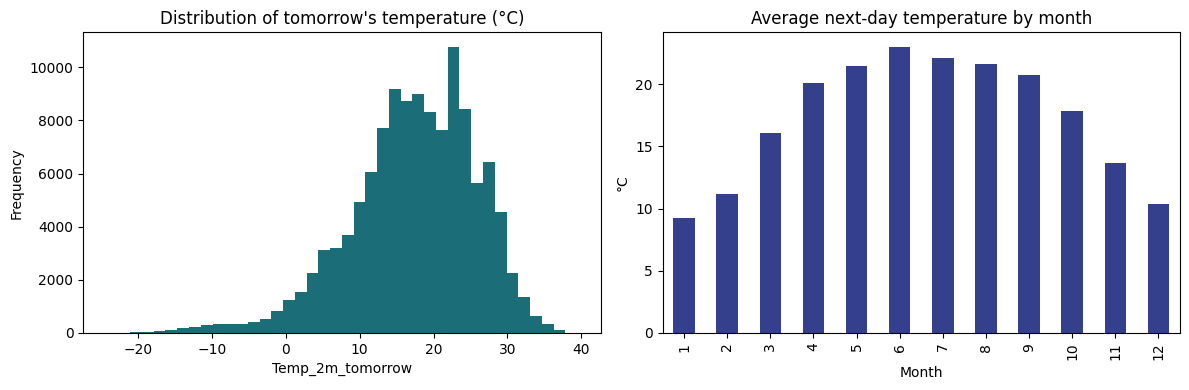

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Temp_2m_tomorrow"].plot(kind="hist", bins=40, ax=axes[0], color="#1B6E77")
axes[0].set_title("Distribution of tomorrow's temperature (\u00b0C)")
axes[0].set_xlabel("Temp_2m_tomorrow")

df.groupby("Month")["Temp_2m_tomorrow"].mean().plot(kind="bar", ax=axes[1], color="#35408C")
axes[1].set_title("Average next-day temperature by month")
axes[1].set_ylabel("\u00b0C")
plt.tight_layout()
plt.show()

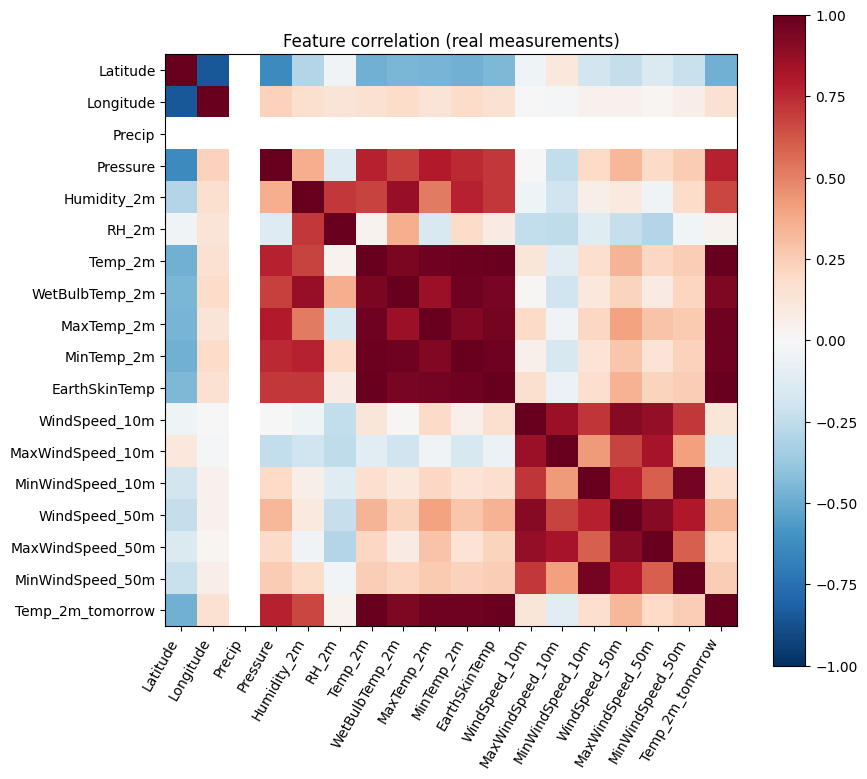

,Temp_2m_tomorrow
Temp_2m_tomorrow,1.000000
Temp_2m,0.994304
EarthSkinTemp,0.985406
MinTemp_2m,0.974870
MaxTemp_2m,0.970838
WetBulbTemp_2m,0.934932
Pressure,0.769657
Humidity_2m,0.670792
WindSpeed_50m,0.334116
MinWindSpeed_50m,0.242943


In [9]:
numeric_cols = ["Latitude", "Longitude", "Precip", "Pressure", "Humidity_2m", "RH_2m",
                "Temp_2m", "WetBulbTemp_2m", "MaxTemp_2m", "MinTemp_2m", "EarthSkinTemp",
                "WindSpeed_10m", "MaxWindSpeed_10m", "MinWindSpeed_10m",
                "WindSpeed_50m", "MaxWindSpeed_50m", "MinWindSpeed_50m", "Temp_2m_tomorrow"]
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols))); ax.set_xticklabels(numeric_cols, rotation=60, ha="right")
ax.set_yticks(range(len(numeric_cols))); ax.set_yticklabels(numeric_cols)
plt.title("Feature correlation (real measurements)")
plt.colorbar(im)
plt.tight_layout()
plt.show()
corr["Temp_2m_tomorrow"].sort_values(ascending=False)

In [10]:
df.groupby("District")[["Temp_2m", "Temp_2m_tomorrow", "Precip"]].mean().round(2).sort_values("Temp_2m", ascending=False).head(10)

,Temp_2m,Temp_2m_tomorrow,Precip
District,,,
Mahottari,25.71,25.71,0.0
Siraha,25.35,25.35,0.0
Kapilvastu,25.26,25.27,0.0
Rautahat,25.13,25.13,0.0
Bara,25.13,25.13,0.0
Parsa,25.13,25.13,0.0
Kailali,24.98,24.99,0.0
Rupandehi,24.80,24.81,0.0
Parasi,24.80,24.81,0.0


## Section 5 — Feature Engineering

The target is **`Temp_2m_tomorrow`** — a genuinely recorded value, not something we
derive ourselves. The inputs are today's real readings for that district: location
(latitude/longitude, which stands in for district identity without one-hot-encoding
77 categories), the day of year (captures season), and the full set of measured
atmospheric variables.

No feature here is allowed to leak the answer: `Temp_2m_tomorrow` is excluded from
`X`, and nothing derived from it is used.

In [11]:
FEATURE_ORDER = [
    "Latitude", "Longitude", "Month", "DayOfYear",
    "Precip", "Pressure", "Humidity_2m", "RH_2m", "Temp_2m", "WetBulbTemp_2m",
    "MaxTemp_2m", "MinTemp_2m", "EarthSkinTemp",
    "WindSpeed_10m", "MaxWindSpeed_10m", "MinWindSpeed_10m",
    "WindSpeed_50m", "MaxWindSpeed_50m", "MinWindSpeed_50m",
]

X = df[FEATURE_ORDER]
y = df["Temp_2m_tomorrow"]
print("Features:", len(FEATURE_ORDER))
X.head()

Features: 19


,Latitude,Longitude,Month,DayOfYear,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m
0,29.12,81.30,7,201,0.0,86.93,19.69,93.48,23.59,23.00,25.70,21.35,23.69,2.31,3.47,0.93,3.10,4.89,1.50
1,27.53,84.35,7,201,0.0,96.05,20.91,91.88,26.52,25.79,29.64,23.91,26.67,2.58,4.22,0.81,3.74,5.86,1.05
2,27.25,85.97,7,201,0.0,78.59,14.77,92.15,17.40,16.64,19.48,14.69,17.36,2.25,4.30,0.67,2.38,3.76,0.93
3,26.98,85.55,7,201,0.0,96.07,20.57,90.03,26.60,25.69,29.14,24.12,26.57,2.70,4.33,1.24,4.06,5.47,2.74
4,29.30,80.58,7,201,0.0,81.40,18.14,91.60,21.56,20.78,24.33,19.04,22.04,2.75,4.96,0.94,3.17,4.86,1.25


## Section 6 — Chronological Train/Test Split

Instead of a random split (which would let the model see readings from days right
next to a test day for the same district), the most recent 20% of the timeline is
held out entirely. The models are trained only on the past and evaluated only on
the future — a fair test of whether they actually generalise to forecasting.

In [12]:
cutoff_date = df["Date"].quantile(0.8, interpolation="nearest")
train_mask = df["Date"] <= cutoff_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Cutoff date:", cutoff_date.date())
print("Train:", X_train.shape, " (", df.loc[train_mask, 'Date'].min().date(), "to", df.loc[train_mask, 'Date'].max().date(), ")")
print("Test: ", X_test.shape, " (", df.loc[~train_mask, 'Date'].min().date(), "to", df.loc[~train_mask, 'Date'].max().date(), ")")

Cutoff date: 2024-06-28
Train: (96776, 19)  ( 2020-07-19 to 2024-06-28 )
Test:  (24155, 19)  ( 2024-06-29 to 2025-07-18 )


In [13]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Section 7 — Train & Compare Three Models

All three train on the identical chronological split so their scores are directly
comparable. Decision Tree and Random Forest use the raw features (tree splits don't
need scaling); SVM trains on the standardized features since it's sensitive to
feature scale.

**Note on SVM:** kernel SVR training cost grows roughly quadratically-to-cubically
with the number of rows, which makes fitting it on the full ~97k-row training set
impractical in a notebook. It's trained on a random subsample of 12,000 training
rows instead — still a substantial, representative sample — while Decision Tree and
Random Forest train on the full training set. All three are still *evaluated* on the
full, untouched test set, so the comparison stays fair.

In [14]:
dt = DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)
print(f"Decision Tree  -> MAE: {dt_mae:.3f}  RMSE: {dt_rmse:.3f}  R2: {dt_r2:.4f}")

Decision Tree  -> MAE: 0.763  RMSE: 1.019  R2: 0.9849


In [15]:
rf = RandomForestRegressor(n_estimators=250, max_depth=16, min_samples_leaf=3,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random Forest  -> MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.4f}")

Random Forest  -> MAE: 0.694  RMSE: 0.922  R2: 0.9876


In [16]:
svm_sample_idx = RNG.choice(len(X_train_scaled), size=min(12000, len(X_train_scaled)), replace=False)
X_train_svm = X_train_scaled[svm_sample_idx]
y_train_svm = y_train.to_numpy()[svm_sample_idx]

svm = SVR(kernel="rbf", C=10.0, epsilon=0.2)
svm.fit(X_train_svm, y_train_svm)
svm_pred = svm.predict(X_test_scaled)

svm_mae = mean_absolute_error(y_test, svm_pred)
svm_rmse = np.sqrt(mean_squared_error(y_test, svm_pred))
svm_r2 = r2_score(y_test, svm_pred)
print(f"SVM (RBF)      -> MAE: {svm_mae:.3f}  RMSE: {svm_rmse:.3f}  R2: {svm_r2:.4f}")

SVM (RBF)      -> MAE: 0.700  RMSE: 1.005  R2: 0.9853


## Section 8 — Compare Results

In [17]:
results = {
    "Decision Tree": {"MAE": dt_mae, "RMSE": dt_rmse, "R2": dt_r2},
    "Random Forest": {"MAE": rf_mae, "RMSE": rf_rmse, "R2": rf_r2},
    "SVM (RBF)":     {"MAE": svm_mae, "RMSE": svm_rmse, "R2": svm_r2},
}
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values("RMSE")
results_df

,MAE,RMSE,R2
Random Forest,0.6945,0.9224,0.9876
SVM (RBF),0.6996,1.0047,0.9853
Decision Tree,0.7634,1.0190,0.9849


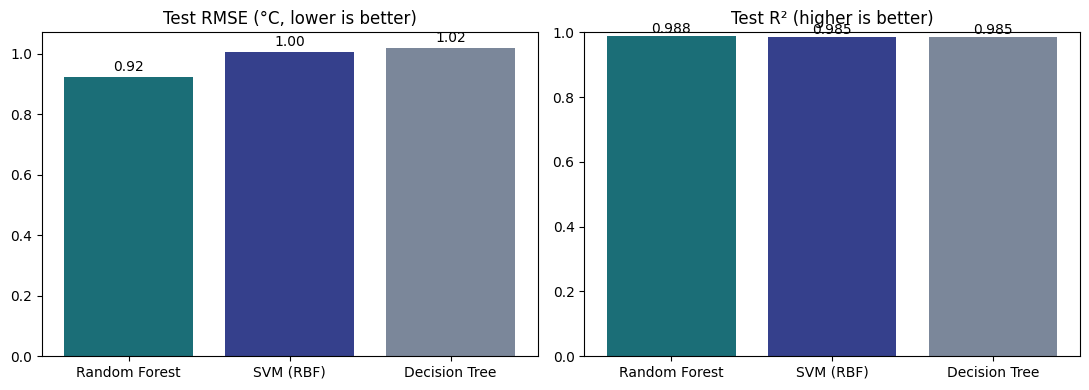

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(results_df.index, results_df["RMSE"], color=["#1B6E77", "#35408C", "#7B879A"])
axes[0].set_title("Test RMSE (\u00b0C, lower is better)")
for i, v in enumerate(results_df["RMSE"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center")

axes[1].bar(results_df.index, results_df["R2"], color=["#1B6E77", "#35408C", "#7B879A"])
axes[1].set_title("Test R\u00b2 (higher is better)")
axes[1].set_ylim(0, 1)
for i, v in enumerate(results_df["R2"]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [19]:
best_name = results_df.index[0]
best_model = {"Decision Tree": dt, "Random Forest": rf, "SVM (RBF)": svm}[best_name]
needs_scaling = best_name == "SVM (RBF)"
best_pred = svm_pred if needs_scaling else (dt_pred if best_name == "Decision Tree" else rf_pred)
print(f"Best model (lowest test RMSE): {best_name}")

Best model (lowest test RMSE): Random Forest


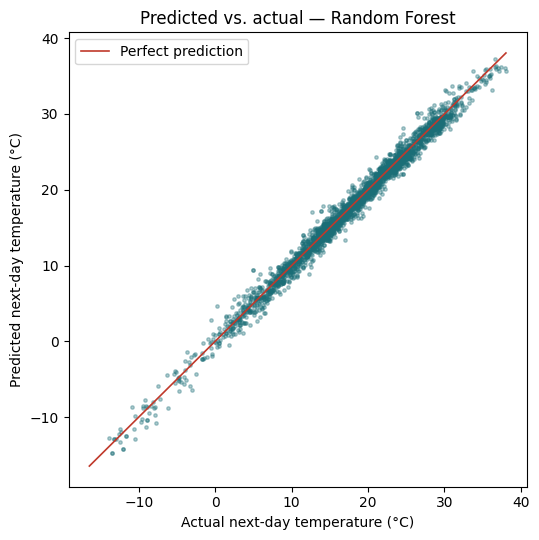

In [20]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sample_idx = RNG.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
y_test_arr = y_test.to_numpy()
ax.scatter(y_test_arr[sample_idx], best_pred[sample_idx], s=6, alpha=0.35, color="#1B6E77")
lims = [min(y_test_arr.min(), best_pred.min()), max(y_test_arr.max(), best_pred.max())]
ax.plot(lims, lims, color="#C0392B", linewidth=1.2, label="Perfect prediction")
ax.set_xlabel("Actual next-day temperature (\u00b0C)")
ax.set_ylabel("Predicted next-day temperature (\u00b0C)")
ax.set_title(f"Predicted vs. actual \u2014 {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

## Section 9 — Feature Importance (Random Forest)

Sanity check: which real measurements is the model actually leaning on?

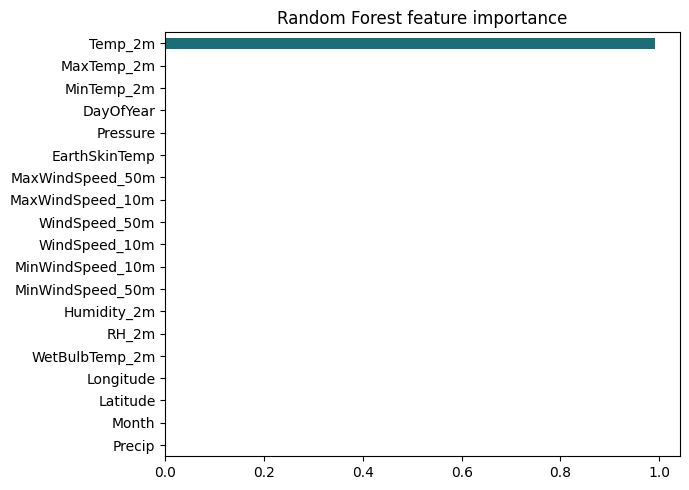

,0
Temp_2m,0.9924
MaxTemp_2m,0.0009
MinTemp_2m,0.0009
DayOfYear,0.0008
Pressure,0.0008
EarthSkinTemp,0.0006
MaxWindSpeed_50m,0.0005
MaxWindSpeed_10m,0.0004
WindSpeed_50m,0.0004
WindSpeed_10m,0.0003


In [21]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_ORDER).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color="#1B6E77")
ax.invert_yaxis()
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.show()
importances.round(4)

## Section 10 — Save Model Artifacts

`app.py` never trains anything — it only loads these files. `model_info.pkl` now
stores real regression metrics (MAE/RMSE/R2 on the held-out future period) instead
of classification accuracy, and there is no `label_encoder.pkl` since there are no
classes to decode — the model outputs a temperature directly.

In [22]:
os.makedirs("../models", exist_ok=True)

joblib.dump(dt, "../models/decision_tree_model.pkl")
joblib.dump(rf, "../models/random_forest_model.pkl", compress=3)  # compress: RF pickles get large uncompressed
joblib.dump(svm, "../models/svm_model.pkl")
joblib.dump(best_model, "../models/best_model.pkl", compress=3)
joblib.dump(scaler, "../models/scaler.pkl")

model_info = {
    "task": "regression",
    "target": "Temp_2m_tomorrow",
    "best_model_name": best_name,
    "feature_order": FEATURE_ORDER,
    "needs_scaling": needs_scaling,
    "metrics": results,
    "train_date_range": [str(df.loc[train_mask, "Date"].min().date()), str(df.loc[train_mask, "Date"].max().date())],
    "test_date_range": [str(df.loc[~train_mask, "Date"].min().date()), str(df.loc[~train_mask, "Date"].max().date())],
}
joblib.dump(model_info, "../models/model_info.pkl")

print("Saved all model artifacts to ../models/")
model_info

Saved all model artifacts to ../models/


{'task': 'regression',
 'target': 'Temp_2m_tomorrow',
 'best_model_name': 'Random Forest',
 'feature_order': ['Latitude',
  'Longitude',
  'Month',
  'DayOfYear',
  'Precip',
  'Pressure',
  'Humidity_2m',
  'RH_2m',
  'Temp_2m',
  'WetBulbTemp_2m',
  'MaxTemp_2m',
  'MinTemp_2m',
  'EarthSkinTemp',
  'WindSpeed_10m',
  'MaxWindSpeed_10m',
  'MinWindSpeed_10m',
  'WindSpeed_50m',
  'MaxWindSpeed_50m',
  'MinWindSpeed_50m'],
 'needs_scaling': False,
 'metrics': {'Decision Tree': {'MAE': 0.7634269316307462,
   'RMSE': np.float64(1.01900132666219),
   'R2': 0.9848722427301798},
  'Random Forest': {'MAE': 0.6944942347850254,
   'RMSE': np.float64(0.9223813860007511),
   'R2': 0.9876050120488645},
  'SVM (RBF)': {'MAE': 0.6995605213075174,
   'RMSE': np.float64(1.004710770762291),
   'R2': 0.985293573230993}},
 'train_date_range': ['2020-07-19', '2024-06-28'],
 'test_date_range': ['2024-06-29', '2025-07-18']}

## Section 11 — Try It on a Real Row

A quick end-to-end check: take one real row from the test set, predict tomorrow's
temperature, and compare to what the dataset says actually happened.

In [23]:
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
sample_input = scaler.transform(sample) if needs_scaling else sample
predicted = best_model.predict(sample_input)[0]

print("District date:", df.loc[sample.index[0], "District"], df.loc[sample.index[0], "Date"].date())
print(f"Predicted tomorrow's temp: {predicted:.2f} \u00b0C")
print(f"Actual tomorrow's temp:    {actual:.2f} \u00b0C")
print(f"Error: {abs(predicted - actual):.2f} \u00b0C")

District date: Salyan 2024-06-29
Predicted tomorrow's temp: 25.43 °C
Actual tomorrow's temp:    24.79 °C
Error: 0.64 °C


---
### Note for `app.py`

This notebook now saves a **regression** pipeline (predicts a real temperature in
\u00b0C) instead of the old **classification** pipeline (predicted a
Sunny/Cloudy/Rainy/Stormy/Foggy label). The existing `app.py`, `templates/index.html`
and `static/js/script.js` were built around the old classification output
(`label_encoder`, `WEATHER_EMOJI`, per-city climatology for the old 10-city dataset)
and will need updating to call `best_model.predict(...)` and display a temperature
instead of a weather-condition label before the web app will run correctly again.